<div style="display:flex; align-items:center; gap:18px; text-align:left">
  <img src="https://sebastiancontz.github.io/ust-diplomado-ia-curso-ml/assets/logo_ust.png" width="100">
  <div>
    <p>Diplomado en Inteligencia Artificial para los Negocios</p>
    <p>Facultad de Ingeniería y Negocios</p>
    <p>Módulo 2: Fundamentos de Machine Learning y herramientas Low Code</p>
    <p>Semana 06: Tuning, interpretación y persistencia</p>
  </div>
</div>

# 06 · Tuning, interpretación y persistencia

Hoy trabajamos con **datos reales**: los **8.000 contactos telefónicos de la campaña de un banco**
(UCI *Bank Marketing*, uno de los datasets de negocio más usados del mundo). Cada fila es una
llamada real a un cliente; el *target* `contrata` dice si terminó contratando un **depósito a
plazo**. La pregunta de negocio: **¿a quién llamamos en la próxima campaña?**

Con ese caso recorremos el camino completo de la clase:

1. **La trampa**: una variable que "sabe la respuesta" — con datos reales.
2. **El experimento honesto** y el ***pipeline* por dentro** (con faltantes reales).
3. **Auditar las variables**: ¿cuántas necesita el modelo? (RFECV).
4. **Tunear**: búsqueda al azar (`tune_model`) y búsqueda inteligente (**Optuna**), mirando **todos los intentos**.
5. **Abrir la caja**: SHAP global, el "porqué" de **un contacto concreto** y PDP.
6. **Comparar** base vs afinado en el *holdout* — **una sola vez** — y auditar con permutación.
7. **Finalizar, guardar y cargar** el modelo: la lista de llamados del lunes.
8. **Valorizar**: la ganancia de la campaña por umbral y el guion para la gerencia.

El mensaje central: **un modelo útil es un modelo evaluado sin trampa, explicado, guardado y
conectado a una decisión**. El código es mínimo: tu trabajo está en **leer y decidir**.

## Preparación del entorno

Instalamos las librerías necesarias para ejecutar el notebook en Colab o en local. La salida queda
oculta para no llenar la pantalla con texto técnico. Novedades de hoy: **`optuna`** (búsqueda
inteligente de hiperparámetros) y **`shap`** (explicar las predicciones).

In [1]:
%%capture
!pip install -q pycaret==4.0.0a8 plotly ipywidgets xgboost catboost lightgbm optuna shap

## Setup técnico

Importaciones y configuración general. No es contenido propio de la clase; solo deja el entorno
listo para que las celdas importantes se concentren en interpretar y decidir.

In [2]:
%matplotlib inline
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from IPython.utils import io          # para silenciar logs verbosos (LightGBM) en celdas puntuales
from sklearn import set_config

# evita que Jupyter/GitHub muestre el pipeline como HTML enorme
set_config(display='text')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Cargar datos

`banco_marketing.csv`: 8.000 contactos **reales** de las campañas telefónicas de un banco
(muestra del dataset UCI *Bank Marketing*, 41.188 llamadas entre 2008 y 2010). Las columnas ya
vienen **traducidas y en números** (los niveles con orden natural, como la educación, van como
códigos), y trae **celdas vacías de verdad** — donde el banco no conocía el dato del cliente.

| Columna | Qué es |
|---|---|
| `edad` | Edad del cliente |
| `educacion` | Nivel educacional (0 = sin estudios … 6 = universitario) |
| `credito_hipotecario` / `credito_consumo` | ¿Tiene ese crédito? (1 = sí; vacío = no se sabe) |
| `duracion_llamada_seg` | Duración de la llamada, en segundos |
| `contactos_esta_campana` / `contactos_previos` | Cuántas veces se le ha llamado |
| `resultado_campana_anterior` | 0 = no participó, 1 = no contrató, 2 = contrató |
| `tasa_euribor` | Tasa de interés de referencia al momento de la llamada |
| `contrata` | **Target**: ¿contrató el depósito a plazo? (1 = sí) |

In [3]:
REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-fundamentos-machine-learning-colab/main/ediciones/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

df = pd.read_csv(BASE + 'banco_marketing.csv')
print('Filas y columnas:', df.shape,
      '| tasa de contratación:', f"{df['contrata'].mean():.1%}",
      '| celdas vacías reales:', int(df.isna().sum().sum()))
df.head()

Filas y columnas: (8000, 10) | tasa de contratación: 11.3% | celdas vacías reales: 690


,edad,educacion,credito_hipotecario,credito_consumo,duracion_llamada_seg,contactos_esta_campana,contactos_previos,resultado_campana_anterior,tasa_euribor,contrata
0,56.0000,4.0000,0.0000,1.0000,307.0000,1.0000,0.0000,0.0000,4.8570,0
1,59.0000,5.0000,0.0000,0.0000,139.0000,1.0000,0.0000,0.0000,4.8570,0
2,41.0000,NaN,0.0000,0.0000,217.0000,1.0000,0.0000,0.0000,4.8570,0
3,57.0000,1.0000,1.0000,0.0000,293.0000,1.0000,0.0000,0.0000,4.8570,0
4,46.0000,2.0000,1.0000,1.0000,440.0000,1.0000,0.0000,0.0000,4.8570,0


Fíjate en el **desbalance**: solo ~11% contrata (¿recuerdas la lección de la Clase 4? el
*accuracy* acá va a engañar — trabajaremos con **AUC**).

# 1. La trampa: ¿demasiado bueno para ser verdad?

Partamos ingenuos: entrenemos un modelo con **todas** las columnas y veamos qué tal.

In [4]:
from pycaret.tasks import ClassificationExperiment

exp_ingenuo = ClassificationExperiment(
    target='contrata', session_id=42, train_size=0.7,
    fold=5, normalize=True, fold_strategy='stratifiedkfold',
).fit(df)

rf_ingenuo = exp_ingenuo.create_model('rf').pipeline
exp_ingenuo.predict_model(rf_ingenuo).metrics

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,RandomForestClassifier,0.9029,0.9322,0.4185,0.5979,0.4924,0.4405,0.4491


In [5]:
importancias = pd.Series(
    rf_ingenuo[-1].feature_importances_,
    index=rf_ingenuo[:-1].get_feature_names_out(),
).sort_values()
fig = px.bar(importancias, orientation='h',
             title='Importancia de variables del modelo ingenuo',
             labels={'value': 'importancia', 'index': ''})
fig.update_layout(showlegend=False)
fig.show()

**Un AUC altísimo y una variable que domina la importancia.** Las **dos señales de alerta**
de la clase, juntas. La variable estrella es `duracion_llamada_seg`… y ahí está la trampa:

> La duración de la llamada **solo se conoce cuando la llamada ya terminó**. Para decidir *a quién
> llamar*, ese dato **no existe todavía**. (Además, es obvio a posteriori: las llamadas donde el
> cliente contrata son largas.) Es una **variable que sabe la respuesta** — la fuga tipo 2 de las
> slides, en un dataset real. Tan real, que la documentación oficial de UCI advierte que esta
> columna "debe descartarse si el objetivo es un modelo predictivo realista".

La sacamos y nos quedamos con el **modelo honesto**: el que solo usa lo que el banco sabe **antes
de marcar el número**.

In [6]:
df = df.drop(columns='duracion_llamada_seg')   # fuera: sabe la respuesta
list(df.columns)

['edad',
 'educacion',
 'credito_hipotecario',
 'credito_consumo',
 'contactos_esta_campana',
 'contactos_previos',
 'resultado_campana_anterior',
 'tasa_euribor',
 'contrata']

# 2. El experimento honesto (y la maleta por dentro)

Ahora sí: experimento con las variables que **sí estarán disponibles** al momento de decidir.
Separación 70/30, validación cruzada estratificada de 5 pliegues y estandarización — la misma
configuración que venimos usando desde la Clase 4.

In [7]:
exp = ClassificationExperiment(
    target='contrata', session_id=42, train_size=0.7,
    fold=5, normalize=True, fold_strategy='stratifiedkfold',
).fit(df)

print('Entrenamiento:', exp.X_train.shape[0], 'contactos | Holdout (prueba):', exp.X_test.shape[0], 'contactos')

Entrenamiento: 5600 contactos | Holdout (prueba): 2400 contactos


Comparamos la galería de modelos de siempre, ordenando por **AUC**.

In [8]:
modelos_clase = ['lr', 'dt', 'rf', 'et', 'gbc', 'xgboost', 'catboost', 'lightgbm']
with io.capture_output():   # silencia los logs de entrenamiento (LightGBM es conversador)
    res = exp.compare_models(include=modelos_clase, sort='AUC', errors='ignore')
res.leaderboard

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,gbc,0.8980,0.7667,0.2203,0.6349,0.3259,0.2849,0.3326
1,catboost,0.8938,0.7557,0.2171,0.5751,0.3141,0.2693,0.3076
2,lightgbm,0.8936,0.7460,0.2504,0.5656,0.3448,0.2965,0.3268
3,rf,0.8921,0.7457,0.2473,0.5499,0.3388,0.2896,0.3182
4,lr,0.8909,0.7362,0.0555,0.7075,0.1026,0.0876,0.1766
5,xgboost,0.8905,0.7250,0.2568,0.5330,0.3455,0.2937,0.3177
6,et,0.8811,0.7216,0.2425,0.4461,0.3127,0.2543,0.2690
7,dt,0.8312,0.6036,0.3106,0.2784,0.2933,0.1979,0.1985


Los ensambles lideran con diferencias chicas. Para el trabajo de hoy elegimos el ***random
forest***: rinde a la par de los punteros, **lo conocemos bien** desde la Clase 3 y conversa sin
fricciones con las herramientas de interpretación que usaremos (SHAP, permutación, RFECV). Ese
será nuestro **modelo base**.

In [9]:
base = exp.create_model('rf')
modelo_base = base.pipeline    # recuerda: create_model devuelve un resultado; el modelo vive en .pipeline
base.metrics

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold 0,0.8938,0.7204,0.2381,0.5660,0.3352,0.2877,0.3199
Fold 1,0.8920,0.7527,0.2143,0.5510,0.3086,0.2621,0.2968
Fold 2,0.8911,0.7876,0.3254,0.5256,0.4020,0.3457,0.3577
Fold 3,0.8955,0.6951,0.2381,0.5882,0.3390,0.2932,0.3289
Fold 4,0.8884,0.7727,0.2205,0.5185,0.3094,0.2593,0.2876
Mean,0.8921,0.7457,0.2473,0.5499,0.3388,0.2896,0.3182
Std,0.0024,0.0339,0.0402,0.0257,0.0340,0.0311,0.0248


## La maleta: el pipeline por dentro

En la Clase 2 PyCaret "preparaba los datos automáticamente". Hoy le ponemos nombre a esa magia:
al llamar a `.fit(df)`, PyCaret construyó un ***pipeline*** — una **cadena de pasos** que empaqueta
la preparación **junto con** el modelo. Mirémoslo:

In [10]:
modelo_base    # la 'maleta': imputar + codificar + escalar + el modelo, en un solo objeto

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numerical_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'educacion',
                                                   'credito_hipotecario',
                                                   'credito_consumo',
                                                   'contactos_esta_campana',
                                                   'contactos_previos',
                                                   'resultado_campana_anterior',
                                                   'tasa_euribor'])],
                                   verbose_feature_na

Tres cosas importantes de esta maleta:

- El **imputador no es decorativo**: este dataset trae **celdas vacías reales** (clientes cuyos
  créditos el banco no conocía) y el pipeline aprendió cómo rellenarlas — **solo con el
  entrenamiento**, nunca mirando el *holdout*. Esa es la defensa de ingeniería contra la **fuga
  tipo 1**.
- Contra la **fuga tipo 2** (la duración) el pipeline **no podía hacer nada**: esa la cazamos
  nosotros, con criterio. Cada defensa en su lugar.
- La maleta viaja **completa**: cuando la guardemos, el escalado y la imputación irán **dentro**
  del archivo.

El **holdout** (2.400 contactos) queda **intacto**: no lo tocaremos hasta la sección 6, y lo
usaremos **una sola vez**.

# 3. ¿Cuántas variables necesita el modelo?

Antes de afinar perillas, auditemos **lo que entra**. Usamos **RFECV** (eliminación recursiva con
validación cruzada): parte con todas las variables, elimina la menos útil, reentrena y repite —
y **decide solo cuántas conservar**. Todo ocurre **dentro del entrenamiento** (el *holdout* ni se
entera).

> Trabajamos sobre la **X ya transformada** por el pipeline (las mismas columnas que ve el modelo).

In [11]:
from sklearn.base import clone
from sklearn.feature_selection import RFECV

pre, modelo_rf = modelo_base[:-1], modelo_base[-1]          # separamos preparación y modelo
X_train_t = pd.DataFrame(pre.transform(exp.X_train), columns=pre.get_feature_names_out())   # OJO: exp.X es TODO el dataset; el train es exp.X_train

rfecv = RFECV(clone(modelo_rf), step=1, cv=3, scoring='roc_auc').fit(X_train_t, exp.y_train)
print('Variables óptimas según RFECV:', rfecv.n_features_, 'de', X_train_t.shape[1])
pd.DataFrame({'variable': X_train_t.columns, 'ranking (1 = se queda)': rfecv.ranking_})

Variables óptimas según RFECV: 6 de 8


,variable,ranking (1 = se queda)
0,edad,1
1,educacion,1
2,credito_hipotecario,1
3,credito_consumo,3
4,contactos_esta_campana,1
5,contactos_previos,2
6,resultado_campana_anterior,1
7,tasa_euribor,1


In [12]:
curva = pd.DataFrame({
    'variables conservadas': range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
    'AUC (validación cruzada)': rfecv.cv_results_['mean_test_score'],
})
fig = px.line(curva, x='variables conservadas', y='AUC (validación cruzada)', markers=True,
              title='¿Cuántas variables necesita el modelo? (RFECV)')
fig.add_vline(x=int(rfecv.n_features_), line_dash='dash', line_color='gray')
fig.show()

**Lectura.** Dos cosas que la curva cuenta:

- **Más variables no siempre es mejor**: con **una sola variable** ya hay bastante modelo
  (AUC ≈ 0,73) y el máximo llega con **6 de las 8** — las candidatas a salir son
  `credito_consumo` y `contactos_previos` (rankings 3 y 2).
- ¿Las sacamos? El método **sugiere**; la decisión es **humana y de negocio**: son datos que el
  banco ya tiene sin costo extra, así que hoy **seguimos con las 8** — pero el diagnóstico queda
  anotado para la próxima iteración. En un caso con 80 variables, esta curva sería plata: cada
  variable de menos es captura, limpieza y mantención que se ahorra.

> La **importancia por permutación** —la medida "honesta" del aporte— la usaremos al final, sobre
> el *holdout*, como **auditoría** del modelo elegido (no para decidir la selección: el *holdout*
> no decide nada).

# 4. Tuning: afinar las perillas

Nuestro *random forest* corre con los hiperparámetros **por defecto**. ¿Cuánto mejora si buscamos
una combinación mejor? Primero, la vía *low-code*: **búsqueda al azar** con `tune_model` — prueba
`n_iter` combinaciones aleatorias, **siempre con validación cruzada** (dentro del entrenamiento).

In [13]:
mejora = exp.tune_model(modelo_base, n_iter=30, optimize='AUC')   # OJO: sin optimize=, buscaría por accuracy
print('La mejor combinación encontrada:')
mejora.best_params

La mejor combinación encontrada:


{'n_estimators': np.int64(60),
 'min_samples_split': 2,
 'min_samples_leaf': 6,
 'min_impurity_decrease': 0.001,
 'max_features': 1.0,
 'max_depth': np.int64(4),
 'criterion': 'gini',
 'class_weight': 'balanced',
 'bootstrap': True}

Lo valioso no es solo el ganador: `cv_results` trae **todos los intentos** de la búsqueda con
su puntaje. Miremos los 10 mejores:

In [14]:
intentos = pd.DataFrame(mejora.cv_results)
col_score = 'mean_test_score'
columnas_param = [c for c in intentos.columns if c.startswith('param_')]
intentos[columnas_param + [col_score]].sort_values(col_score, ascending=False).head(10)

,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_min_impurity_decrease,param_max_features,param_max_depth,param_criterion,param_class_weight,param_bootstrap,mean_test_score
11,60,2,6,0.0010,1.0000,4,gini,balanced,True,0.7695
8,120,5,6,0.0000,sqrt,9,gini,{},True,0.7584
14,20,10,2,0.0100,log2,6,entropy,balanced_subsample,True,0.7566
7,230,10,6,0.0000,sqrt,9,entropy,{},True,0.7562
6,120,2,3,0.0100,log2,4,entropy,balanced_subsample,True,0.7548
12,230,5,5,0.0100,sqrt,5,entropy,balanced_subsample,True,0.7548
15,10,9,5,0.0005,1.0000,6,gini,balanced_subsample,True,0.7533
21,250,5,6,0.0005,sqrt,3,gini,balanced,True,0.7530
13,60,10,3,0.0001,sqrt,9,entropy,balanced_subsample,True,0.7525
10,140,5,5,0.0020,sqrt,2,gini,balanced_subsample,True,0.7468


> **ADVERTENCIA (verificada en esta versión de PyCaret):** el resultado del *tuning* **puede
> ser peor** que el modelo original, y nadie te avisa. **Comparar base vs afinado es tu trabajo** —
> y esa comparación honesta se hace **una sola vez**, en el *holdout* (sección 6).

## Búsqueda inteligente con Optuna

La búsqueda al azar tira dardos repartidos. **Optuna** tira dardos que **aprenden**: cada intento
usa los resultados anteriores para concentrarse donde hubo buenos puntajes (la estrategia se llama
TPE; nos basta la intuición).

La celda siguiente es una **demo para leer** (no hay que memorizarla): definimos qué perillas
explorar y dejamos que Optuna proponga 30 intentos sobre **el mismo pipeline completo** — así el
preprocesamiento va incluido y no hay fuga. Fíjate en los **tipos de perilla**: dos son **números
enteros** (`suggest_int`) y una es **categórica** (`suggest_categorical`) — Optuna maneja ambos
sin drama.

In [15]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)   # silencio: solo queremos el resultado

def objetivo(trial):
    p = clone(modelo_base)                             # copia fresca del pipeline COMPLETO
    p.set_params(**{
        'rf__n_estimators': trial.suggest_int('n_estimators', 20, 300),          # perilla entera
        'rf__max_depth':    trial.suggest_int('max_depth', 2, 14),               # perilla entera
        'rf__criterion':    trial.suggest_categorical('criterion',               # perilla CATEGÓRICA
                                                      ['gini', 'entropy']),
    })
    return cross_val_score(p, exp.X_train, exp.y_train, cv=3, scoring='roc_auc').mean()

estudio = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
estudio.optimize(objetivo, n_trials=30, show_progress_bar=False)

print('Mejor combinación según Optuna:', estudio.best_params,
      '| AUC (CV):', round(estudio.best_value, 4))

Mejor combinación según Optuna: {'n_estimators': 264, 'max_depth': 5, 'criterion': 'entropy'} | AUC (CV): 0.7574


Igual que antes, la historia completa está en la tabla de intentos — y aquí se **ve** el
aprendizaje: los primeros intentos exploran; los últimos se concentran en la zona buena.

In [16]:
trials = estudio.trials_dataframe()[['number', 'params_n_estimators', 'params_max_depth',
                                     'params_criterion', 'value']]
trials.columns = ['intento', 'n_estimators', 'max_depth', 'criterion', 'AUC (CV)']

fig = px.scatter(trials, x='n_estimators', y='max_depth', color='AUC (CV)',
                 symbol='criterion',                       # la perilla categórica, como forma
                 hover_data=['intento'], color_continuous_scale='viridis',
                 title='Los 30 intentos de Optuna: la búsqueda se concentra donde hay premio')
fig.update_traces(marker=dict(size=13, line=dict(width=1, color='white')))
fig.show()

Optuna además trae sus **propios gráficos** (una línea cada uno). El primero es la
**historia de la búsqueda**: el puntaje de cada intento y la línea del **mejor hasta ese
momento** — aquí se ve la búsqueda *aprendiendo*… hasta que la curva **se aplana** (los últimos intentos
ya casi no mejoran: rendimientos decrecientes en vivo).

In [17]:
from optuna.visualization import plot_optimization_history, plot_param_importances

fig = plot_optimization_history(estudio)
fig.update_layout(title='La historia de la búsqueda: cada intento y el mejor hasta ese momento',
                  xaxis_title='intento', yaxis_title='AUC (CV)')
for tr in fig.data:
    tr.name = {'Objective Value': 'puntaje del intento', 'Best Value': 'mejor hasta ahora'}.get(tr.name, tr.name)
fig.show()

Y el segundo responde una pregunta muy de esta clase — **¿qué perilla movió más el
puntaje?** — con una vieja conocida: la **importancia**… pero de los *hiperparámetros*.

In [18]:
fig = plot_param_importances(estudio)
fig.update_layout(title='¿Qué perilla movió más el puntaje de la búsqueda?',
                  xaxis_title='importancia (según la búsqueda)', yaxis_title='')
fig.show()

**Lectura.** La profundidad (`max_depth`) es la perilla que más pesa (~la mitad de la
importancia) — coherente con la curva en U de las slides: es LA perilla de la complejidad. El
número de árboles le sigue, y el `criterion` casi no importa (~7%): la perilla categórica que
agregamos "por si acaso" resultó irrelevante — dato útil en sí mismo. Si mañana repites esta
búsqueda con menos presupuesto, ya sabes dónde concentrarte.

**Lectura y expectativa realista.** Las dos búsquedas llegan a zonas parecidas (poca
profundidad, decenas de árboles) y la mejora sobre el modelo por defecto se mide en **décimas** —
el *tuning* es el **pulido final**; mejores datos y mejores variables mueven más que mejores
perillas. La ganancia real de este bloque es otra: ahora sabes **leer una búsqueda** y explicar
qué estrategia usó.

# 5. Abrir la caja: ¿por qué decide lo que decide?

El modelo rinde — pero ¿lanzarías una campaña sobre miles de clientes sin saber **por qué** eligió
a quién llamar? Abrimos la caja en dos niveles: **global** (qué pesa en general) y **local** (por
qué **este** contacto).

## SHAP global: qué mueve las predicciones

Cada punto es un contacto; el color, el valor de su variable; la posición horizontal, su **empuje**
sobre la predicción (izquierda = menos probable que contrate, derecha = más probable).

In [19]:
exp.plot_model(modelo_base, plot='shap_beeswarm')

**Lectura.** La variable que más mueve la aguja es la **tasa de interés** del momento
(euríbor): con tasas **bajas** (puntos azules a la derecha) la contratación se dispara — el
**contexto económico** pesa más que cualquier dato del cliente. Le siguen la **edad** y el
**resultado de la campaña anterior** (quien ya contrató antes, tiende a repetir). Cuando el
gráfico calza con la lógica del negocio, gana confianza; cuando muestra algo raro, es una
**alerta de auditoría** (¿fuga de datos? ¿sesgo?).

## SHAP local: ¿por qué ESTE contacto?

Tomemos el contacto con **mayor probabilidad** según el modelo y despiecemos su predicción: desde
el **valor base** (la tasa de contratación promedio, ~11%), cada variable **empuja** hacia arriba
o hacia abajo.

In [20]:
import shap

explicador = shap.TreeExplainer(modelo_rf)
X_expl = pd.DataFrame(pre.transform(exp.X_train), columns=pre.get_feature_names_out())
explicacion = explicador(X_expl)
expl_pos = explicacion[:, :, 1] if len(explicacion.shape) == 3 else explicacion  # clase positiva

probs = modelo_base.predict_proba(exp.X_train)[:, 1]
contacto = int(np.argmax(probs))
print('Contacto analizado (fila', contacto, ') | probabilidad de contratar:', f'{probs[contacto]:.0%}')
exp.X_train.iloc[[contacto]]

Contacto analizado (fila 1964 ) | probabilidad de contratar: 98%


,edad,educacion,credito_hipotecario,credito_consumo,contactos_esta_campana,contactos_previos,resultado_campana_anterior,tasa_euribor
7963,37.0000,6.0000,0.0000,0.0000,2.0000,2.0000,2.0000,1.0250


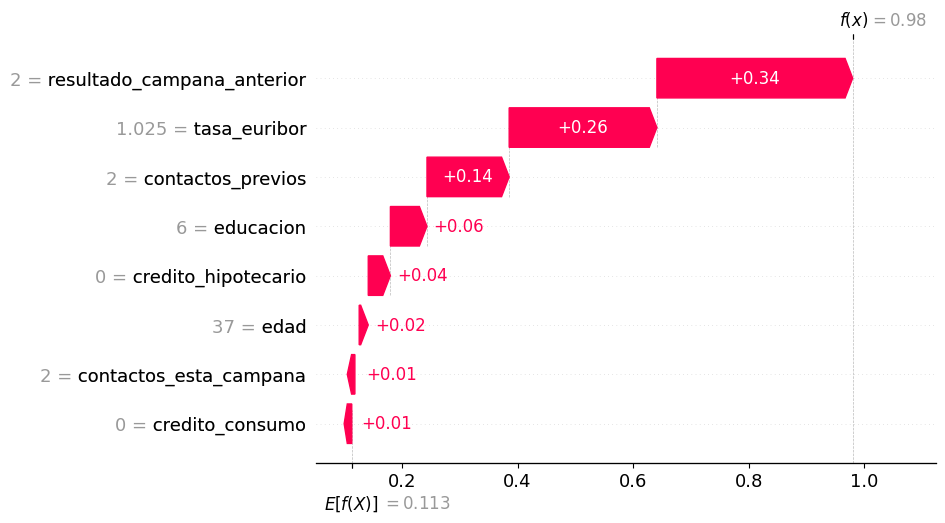

In [21]:
# el waterfall muestra los valores CRUDOS del contacto (no los escalados), para que se lea natural
expl_contacto = shap.Explanation(
    values=expl_pos[contacto].values,
    base_values=float(expl_pos[contacto].base_values),
    data=exp.X_train.iloc[contacto].values,
    feature_names=list(exp.X_train.columns),
)
shap.plots.waterfall(expl_contacto)

**Lectura.** Este contacto llega a una probabilidad altísima empujado por su **resultado en
la campaña anterior** (ya contrató antes) y por el **momento de tasas**; sus datos personales casi
no pesan *en su caso*. Esto convierte una probabilidad en una **conversación**: el ejecutivo no lo
llama "porque el modelo lo dijo", lo llama **porque es un cliente que ya confió antes y el momento
acompaña**. Y ante un regulador, esta es la respuesta al "¿por qué me contactaron/clasificaron
así?".

## PDP: el efecto de una variable, aislado

El **gráfico de dependencia parcial** (*partial dependence plot*) muestra cómo cambia la
predicción promedio al mover **una** variable, dejando el resto constante.

In [22]:
exp.plot_model(modelo_base, plot='pdp', feature='edad')

**Lectura.** La curva de la edad **no es una línea recta**: la probabilidad es más alta en
los **jóvenes** y en los **mayores**, y más baja en la edad media — la clásica forma en U de este
negocio (estudiantes y jubilados contratan más depósitos). Un modelo lineal se lo habría perdido;
los árboles lo capturan solos.

## El PDP como análisis de sensibilidad: la tasa

Apliquemos el mismo gráfico a la **variable estrella** del modelo. Barrer la `tasa_euribor` de
punta a punta es preguntarle al modelo: *¿qué tan sensible es la contratación al momento de
tasas?* — casi un **análisis de escenarios** (¿cómo se vería la campaña en un mundo de tasas
altas?).

In [23]:
exp.plot_model(modelo_base, plot='pdp', feature='tasa_euribor')

**Lectura.** La sensibilidad es **enorme**: con tasas **bajas** la probabilidad de contratar
se dispara; al subir la tasa, cae y se aplana. Ninguna otra variable mueve tanto la aguja —
coherente con el SHAP global.

> **La advertencia que corresponde:** esto mide la sensibilidad **del modelo**, no **del mundo**.
> El PDP le re-pregunta al modelo con la tasa editada; NO dice qué pasaría *causalmente* si el
> Banco Central la mueve (el modelo aprendió la correlación del período 2008–2010, no una ley
> económica). Además es un **promedio**: puede esconder que a unos clientes la tasa los mueve
> mucho y a otros nada (para eso existen las curvas ICE, el primo caso-a-caso del PDP).
> Y la regla general de siempre: importancia **no es causalidad** — si una variable dominara
> "mágicamente", la sospecha correcta es **fuga de datos** (como nos pasó con la duración), no un
> descubrimiento.

# 6. La comparación única en el holdout

Llegó el momento de usar el examen final — **una sola vez**. ¿El modelo afinado es realmente mejor
que el base **fuera** de la búsqueda?

In [24]:
res_base = exp.predict_model(modelo_base)
res_afinado = exp.predict_model(mejora.pipeline)

comparacion = pd.concat([res_base.metrics, res_afinado.metrics])
comparacion.index = ['Base (rf por defecto)', 'Afinado (tune_model)']
comparacion

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Base (rf por defecto),RandomForestClassifier,0.8817,0.7081,0.1926,0.4407,0.2680,0.2143,0.2362
Afinado (tune_model),RandomForestClassifier,0.7992,0.7517,0.6111,0.3044,0.4064,0.3015,0.3281


In [25]:
auc_base = float(res_base.metrics['AUC'].iloc[0])
auc_afinado = float(res_afinado.metrics['AUC'].iloc[0])

elegido = mejora.pipeline if auc_afinado >= auc_base else modelo_base
print(f'AUC en holdout — base: {auc_base:.4f} | afinado: {auc_afinado:.4f}')
print('Elegido:', 'el AFINADO' if elegido is mejora.pipeline else 'el BASE',
      '(la comparación decide, no la costumbre)')

AUC en holdout — base: 0.7081 | afinado: 0.7517
Elegido: el AFINADO (la comparación decide, no la costumbre)


**Lectura.** El afinado mejora con claridad — más de lo habitual para un *tuning*, y con
razón: la búsqueda dirigida al AUC eligió, entre otras perillas, **pesos balanceados para la clase
minoritaria** (`class_weight='balanced'`), justo lo que un problema desbalanceado agradece
(¿recuerdas la Clase 4?). El *holdout* confirma que la mejora **se sostiene** fuera de la
búsqueda. Si el afinado hubiera salido **peor**, nos quedábamos con el base sin drama: para eso
era la comparación.

## Auditoría final: importancia por permutación

Ahora que el *holdout* ya cumplió su rol de examen, lo usamos para **auditar** el modelo elegido
(mirar y entender — ya no decide nada): desordenamos cada variable y medimos cuánto **duele** en
el AUC.

In [26]:
from sklearn.inspection import permutation_importance

pfi = permutation_importance(elegido, exp.X_test, exp.y_test,
                             scoring='roc_auc', n_repeats=10, random_state=42)
tabla_pfi = pd.DataFrame({'variable': exp.X.columns, 'caída de AUC al permutar': pfi.importances_mean}) \
              .sort_values('caída de AUC al permutar')
fig = px.bar(tabla_pfi, x='caída de AUC al permutar', y='variable', orientation='h',
             title='Auditoría por permutación (en el holdout): ¿cuánto duele perder cada variable?')
fig.show()

**Lectura.** La permutación cuenta la historia **honesta**: la **tasa de interés** es la
columna vertebral del modelo (permutarla duele mucho) y la **edad** aporta; el resto mueve poco —
coherente con lo que dijo RFECV en la sección 3. Ninguna dominancia "mágica" como la de la
duración → sin señales de fuga. Auditoría aprobada.

# 7. Finalizar, guardar y usar

El modelo está elegido, evaluado y auditado. Tres pasos para sacarlo del notebook, **en este
orden**:

1. **Finalizar**: reentrenar con el **100% de los datos** (el examen ya se rindió; ahora esos
   datos aportan experiencia).
2. **Guardar** la maleta completa (preprocesamiento + modelo) en un archivo.
3. **Cargar** y usar donde se necesite.

In [27]:
final = exp.finalize_model(elegido)
ruta = exp.save_model(final.pipeline, 'modelo_campana')
print('Modelo guardado en:', ruta)

Modelo guardado en: /home/sebastian/Documents/ust-diplomado-ia-curso-ml-2026/ediciones/2026/notebooks/modelo_campana.pkl


In [28]:
modelo_produccion = exp.load_model('modelo_campana')
type(modelo_produccion)    # el pipeline completo, listo para predecir datos CRUDOS

sklearn.pipeline.Pipeline

## El lunes a las 9: la lista de llamados

Simulemos el despliegue mínimo: llega la **base de clientes para la próxima campaña** (sin
etiqueta, obvio — aún nadie los ha llamado) y el proceso genera la **lista priorizada** para el
*call center*.

In [29]:
proxima_campana = df.drop(columns='contrata').sample(8, random_state=7).reset_index(drop=True)

lista = proxima_campana.copy()
lista['prob_contrata'] = modelo_produccion.predict_proba(proxima_campana)[:, 1]
lista.sort_values('prob_contrata', ascending=False)

,edad,educacion,credito_hipotecario,credito_consumo,contactos_esta_campana,contactos_previos,resultado_campana_anterior,tasa_euribor,prob_contrata
3,34.0000,4.0000,1.0000,0.0000,3.0000,1.0000,1.0000,1.2500,0.5985
5,49.0000,1.0000,1.0000,1.0000,4.0000,0.0000,0.0000,4.9630,0.3339
2,35.0000,3.0000,0.0000,1.0000,1.0000,0.0000,0.0000,4.8640,0.2882
4,49.0000,6.0000,0.0000,0.0000,1.0000,0.0000,0.0000,4.8580,0.2821
1,53.0000,2.0000,1.0000,0.0000,3.0000,0.0000,0.0000,4.1200,0.2789
7,47.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,4.8560,0.2749
6,45.0000,4.0000,1.0000,0.0000,2.0000,0.0000,0.0000,1.3270,0.2399
0,49.0000,3.0000,0.0000,1.0000,16.0000,0.0000,0.0000,4.9680,0.0295


Eso es **desplegar** en su forma mínima: un archivo `.pkl` + un proceso que corre antes de
cada campaña. Sin APIs ni infraestructura épica — y ya genera valor.

> **La advertencia de la maleta:** guarda siempre el **pipeline completo**. Si guardaras solo el
> modelo, estos datos crudos (con celdas vacías y sin escalar) lo harían fallar — o peor, predecir
> mal en silencio. Y recuerda que **los modelos envejecen**: este dataset lo demuestra solo — la
> tasa euríbor de 2008 no es la de hoy; si el histograma de probabilidades cambia de forma, toca
> revisar (de eso se trata **MLOps**, Clase 8).

# 8. La cuenta: de la métrica a la decisión

Cerramos el ciclo. El AUC no basta: la **decisión** sí. Pongamos **precios** a la
matriz de confusión de la campaña (por contacto):

| Celda | Qué pasó | Cuenta | Resultado |
|---|---|---|---|
| **VP** | Llamamos y contrata | \$60.000 de margen − \$5.000 de llamada | **+\$55.000** |
| **FP** | Llamamos y no contrata | costo de la llamada | **−\$5.000** |
| **FN** | No llamamos a quien habría contratado | oportunidad perdida | \$0 (estado base) |
| **VN** | No llamamos a quien no contrataría | — | \$0 |

Con esos precios, calculamos la **ganancia neta** de la campaña para **cada umbral** posible.

> **Nota fina:** para cerrar el ejemplo calculamos esta curva sobre el *holdout*; en rigor, el
> umbral también se calibra en datos de validación aparte (o con validación cruzada) **antes** de
> tocar el examen final.

**La IA como copiloto:** la celda que viene es el código más largo del curso — y **no hay que
memorizarlo**. Lo importante es saber **qué pedir**. Un prompt como este te lo genera con
cualquier asistente de IA:

> *"Tengo un modelo de clasificación binaria en Python (scikit-learn). `prob_holdout` tiene las
> probabilidades predichas y `y_real` las etiquetas verdaderas (0/1). Cada verdadero positivo me
> deja \$55.000 netos y cada falso positivo me cuesta \$5.000. Recorre umbrales entre 0 y 1,
> calcula la ganancia neta total para cada uno, grafica la curva con plotly y márcame el umbral
> óptimo. Agrega dos líneas de referencia: 'no llamar a nadie' (\$0) y 'llamar a todos'."*

Fíjate en lo que el prompt exige **de ti**: conocer tus datos, tus **costos** y tu **decisión** —
la parte que ninguna IA puede poner. Esto es lo que devuelve (adaptado a nuestros nombres):

In [30]:
MARGEN, COSTO_LLAMADA = 60_000, 5_000

prob_holdout = elegido.predict_proba(exp.X_test)[:, 1]
y_real = np.asarray(exp.y_test)

umbrales = np.linspace(0.02, 0.90, 89)
ganancias = []
for u in umbrales:
    llamar = prob_holdout >= u
    vp = int(((y_real == 1) & llamar).sum())      # llamados que contratan
    fp = int(((y_real == 0) & llamar).sum())      # llamadas perdidas
    ganancias.append(vp * (MARGEN - COSTO_LLAMADA) - fp * COSTO_LLAMADA)

curva_ganancia = pd.DataFrame({'umbral': umbrales, 'ganancia neta ($)': ganancias})
optimo = curva_ganancia.loc[curva_ganancia['ganancia neta ($)'].idxmax()]

llamar_a_todos = int((y_real == 1).sum() * (MARGEN - COSTO_LLAMADA) - (y_real == 0).sum() * COSTO_LLAMADA)
fig = px.line(curva_ganancia, x='umbral', y='ganancia neta ($)',
              title='La ganancia de la campaña, umbral por umbral')
fig.add_hline(y=0, line_dash='dot', line_color='gray', annotation_text='no llamar a nadie ($0)')
fig.add_hline(y=llamar_a_todos, line_dash='dash', line_color='red', annotation_text='llamar a todos')
fig.add_vline(x=float(optimo['umbral']), line_dash='dash', line_color='orange')
fig.show()

n_llamados = int((prob_holdout >= optimo['umbral']).sum())
captados = int(((y_real == 1) & (prob_holdout >= optimo['umbral'])).sum())
print(f"Umbral óptimo: {optimo['umbral']:.2f} | ganancia neta: ${optimo['ganancia neta ($)']:,.0f}")
print(f"Llamados: {n_llamados} de {len(y_real)} | contratos captados: {captados} de {int((y_real == 1).sum())}")
print(f"Llamar a TODOS también es rentable (${llamar_a_todos:,.0f}) — pero el modelo agrega "
      f"${int(optimo['ganancia neta ($)']) - llamar_a_todos:,.0f} más, ahorrándose las llamadas perdidas.")

Umbral óptimo: 0.48 | ganancia neta: $7,320,000
Llamados: 552 de 2400 | contratos captados: 168 de 270
Llamar a TODOS también es rentable ($4,200,000) — pero el modelo agrega $3,120,000 más, ahorrándose las llamadas perdidas.


**El guion de cuatro líneas para la gerencia** (los mismos números de las slides):

1. **Qué hace**: ordena a los clientes según su probabilidad de contratar el depósito.
2. **Qué tan bien**: de cada 10 que contratarían, capta **6** llamando a **menos de un cuarto** de la base.
3. **Qué decisión habilita**: llamar a los **552 más probables** cuesta **\$2,8 millones** y deja
   **\$7,3 millones** de ganancia neta — **\$3,1 millones más** que llamar a todos.
4. **Qué límites tiene**: envejece (las tasas de 2008 no son las de hoy) y las cifras dependen de
   los costos supuestos.

Fíjate además en el umbral óptimo (**≈ 0,48**): no es el 0,5 "por costumbre" — es la **cresta de
la curva**, y se movería si cambian los precios. El umbral **se calcula con la cuenta del
negocio**: si la llamada se encarece, el óptimo **sube** (hay que estar más seguros antes de
gastar).

# Ahora tú

Cuatro desafíos para cerrar el ciclo con tus propias manos. Las **soluciones** se publican después
de la sesión.

**1. Más intentos, ¿mejor tuning?** Repite `tune_model` con `n_iter=60` (el doble de intentos) y
`optimize='AUC'`. ¿Mejora la validación cruzada respecto de `n_iter=30`? ¿Vale la pena el doble de
tiempo de cómputo?

In [31]:
# tu código aquí


**2. El porqué de otro contacto.** Elige un contacto del entrenamiento con probabilidad
**baja** (pista: `np.argmin(probs)`) y construye su explicación local (waterfall). ¿Qué variables
lo alejan de contratar? Escribe la explicación en una frase para un ejecutivo.

In [32]:
# tu código aquí


**3. Auditor por un día.** Carga `credito_aleman.csv` (está en la misma carpeta de datasets:
1.000 solicitudes de crédito **reales**, target `incumplimiento`). Entrena un clasificador y mira
su SHAP global. Anota: (a) dos patrones que calzan con la intuición, (b) un patrón que te
obligaría a hacer preguntas antes de confiar en el modelo.

In [33]:
# tu código aquí (pista: es el mismo flujo — Experiment → create_model('rf') → plot shap_beeswarm)


**4. La cuenta con otros precios.** Recalcula la curva de ganancia suponiendo que la llamada
se encarece a **\$15.000** (un canal presencial, por ejemplo). ¿Hacia dónde se movió el umbral
óptimo? ¿Sigue conviniendo llamar a todos?

In [34]:
# tu código aquí


# Para llevar

- **La regla de oro** contra la fuga: todo dato que use el modelo debe existir **antes** de la
  decisión (la duración de la llamada no existía) y todo número de preparación debe poder
  calcularse **solo con el entrenamiento**; el *holdout* se usa **una vez**.
- Los métodos de selección y el *tuning* **sugieren**; comparar y decidir es **tu** trabajo.
- SHAP convierte una probabilidad en una **conversación** (global para la política, local para el
  caso); importancia **no es causalidad**.
- Se guarda la **maleta completa** (evaluar → finalizar → guardar) y el modelo vale cuando un
  proceso lo **ejecuta** — y alguien fija el **umbral con la cuenta del negocio**, no con el 0,5.

**Material de estudio:** las slides, la guía (web + PDF), las tarjetas de repaso y este notebook.
Nos vemos en la **Clase 07 · Introducción a Forecasting**.

<!-- migracion-modular: atribucion-datos -->
## Atribución de datos

**Creador:** S. Moro, P. Rita y P. Cortez (Bank Marketing); Hans Hofmann (Statlog German Credit Data).
**Fuente:** [UCI Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) y [UCI Statlog German Credit Data](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data).
**Licencia:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) para ambos datasets.
**Modificación:** muestra estratificada, columnas traducidas/codificadas y selección de variables para las actividades de modelado e interpretación.
